In [34]:
#Jake Manders Deep Learning Assignment 1

In [35]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import PIL
import requests
import random

In [36]:
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

In [37]:
from tqdm.notebook import tqdm
import numpy as np
import torch
import PIL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("We are using {}".format(device))

We are using cpu


In [38]:
# Create Dataset and DataLoader objects for provided training and validation data (folders train and val).

from torchvision.datasets import ImageFolder
from torchvision.transforms import Resize, ToTensor, Normalize, Compose
from torchvision.utils import make_grid

root_dir_train = 'chest_xray_64/train'
root_dir_val = 'chest_xray_64/val'

target_size = (64, 64)
transforms = Compose([Resize(target_size), # Resizes image
                    ToTensor(),           # Converts to Tensor, scales to [0, 1] float (from [0, 255] int)
                    Normalize(mean=(0.5, 0.5, 0.5,), std=(0.5, 0.5, 0.5)), # scales to [-1.0, 1.0]
                    ])

train_dataset = ImageFolder(
    root_dir_train, 
    transforms, 
    is_valid_file=lambda x: x.endswith("jpeg"))

val_dataset = ImageFolder(
    root_dir_val, 
    transforms, 
    is_valid_file=lambda x: x.endswith("jpeg"))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(val_dataset)}')


Train dataset size: 5216
Validation dataset size: 624


Training images:


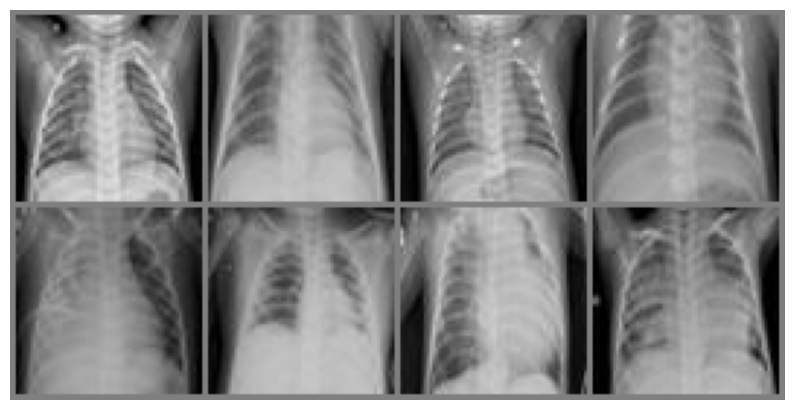

Validation images:


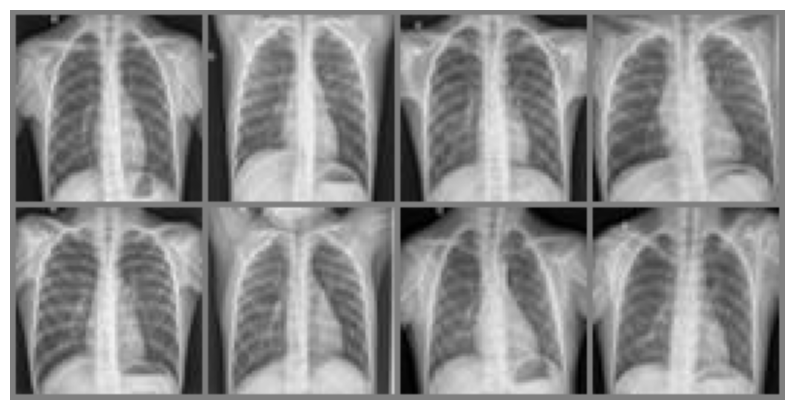

In [39]:
# Visualise a few images frim each class.

def show_images(loader, num_images):
    images, labels = next(iter(loader)) 
    images = make_grid(images[:num_images], nrow=4)  
    images = images / 2 + 0.5  
    
    np_images = images.numpy().transpose((1, 2, 0))

    plt.figure(figsize=(10, 10))
    plt.imshow(np_images)
    plt.axis('off')
    plt.show()

print("Training images:")
show_images(train_loader, 8)

print("Validation images:")
show_images(val_loader, 8)

In [40]:
# Implement the MLP model according to the definition below:

import torch.nn as nn
    
class MLPModel(nn.Module):
    
    def __init__(self, input_dim, hidden_dim):
        super(MLPModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )
    
    def forward(self, input):
        input = input.view(input.size(0), -1)
        return self.layers(input)

In [41]:
# MLP layers:

model = MLPModel(64*64*3, 128)
print(model)

MLPModel(
  (layers): Sequential(
    (0): Linear(in_features=12288, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [42]:
# Implement a convulational model

class ConvModel(nn.Module):
    
    def __init__(self):
        super(ConvModel, self).__init__()
        self.conv_layers = nn.Sequential(

            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True),
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=2, stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1),
            nn.ReLU(),

            nn.Conv2d(in_channels=256, out_channels=2, kernel_size=1, stride=1),
        )
    
    def forward(self, input):
        output = self.conv_layers(input)
        return output.view(output.size(0), -1)

In [43]:
# CNN layers:

model2 = ConvModel()
print(model2)

ConvModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 128, kernel_size=(2, 2), stride=(1, 1))
    (10): ReLU()
    (11): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
    (12): ReLU()
    (13): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
    (14): ReLU()
    (15): Conv2d(256, 2, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [44]:
import numpy as np

def train_epoch(model, train_dataloader, optimizer, loss_fn):
    losses = []
    correct_predictions = 0
    # Iterate mini batches over training dataset
    for images, labels in tqdm(train_dataloader):
        images = images.to(device)
        labels = labels.to(device)
        # Run predictions
        output = model(images)
        # Set gradients to zero
        optimizer.zero_grad()
        # Compute loss
        loss = loss_fn(output, labels)
        # Backpropagate (compute gradients)
        loss.backward()
        # Make an optimization step (update parameters)
        optimizer.step()
        # Log metrics
        losses.append(loss.item())
        predicted_labels = output.argmax(dim=1)
        correct_predictions += (predicted_labels == labels).sum().item()
    accuracy = 100.0 * correct_predictions / len(train_dataloader.dataset)
    # Return loss values for each iteration and accuracy
    mean_loss = np.array(losses).mean()
    return mean_loss, accuracy


In [45]:
def evaluate(model, dataloader, loss_fn):
    losses = []
    correct_predictions = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            # Run predictions
            output = model(images)
            # Compute loss
            loss = loss_fn(output, labels)
            # Save metrics
            predicted_labels = output.argmax(dim=1)
            correct_predictions += (predicted_labels == labels).sum().item()
            losses.append(loss.item())
    mean_loss = np.array(losses).mean()
    accuracy = 100.0 * correct_predictions / len(dataloader.dataset)
    # Return mean loss and accuracy
    return mean_loss, accuracy


In [46]:
def train(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn):
    # We will monitor loss functions as the training progresses
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(n_epochs):
        model.train()
        train_loss, train_accuracy = train_epoch(model, train_dataloader, optimizer, loss_fn)
        model.eval()
        val_loss, val_accuracy = evaluate(model, val_dataloader, loss_fn)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        print('Epoch {}/{}: train_loss: {:.4f}, train_accuracy: {:.4f}, val_loss: {:.4f}, val_accuracy: {:.4f}'.format(epoch+1, n_epochs,
                                                                                                      train_losses[-1],
                                                                                                      train_accuracies[-1],
                                                                                                      val_losses[-1],
                                                                                                      val_accuracies[-1]))
    return train_losses, val_losses, train_accuracies, val_accuracies

In [47]:
def plot(train_losses, val_losses, train_accuracies, val_accuracies, title):
    plt.figure()
    plt.plot(np.arange(len(train_losses)), train_losses)
    plt.plot(np.arange(len(val_losses)), val_losses)
    plt.legend(['train_loss', 'val_loss'])
    plt.xlabel('epoch')
    plt.ylabel('loss value')
    plt.title('{}: Train/val loss'.format(title));

    plt.figure()
    plt.plot(np.arange(len(train_accuracies)), train_accuracies)
    plt.plot(np.arange(len(val_accuracies)), val_accuracies)
    plt.legend(['train_acc', 'val_acc'])
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('{}: Train/val accuracy'.format(title));

In [48]:
model = model.to(device)
learning_rate = 0.001 #1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
n_epochs = 30
loss_fn = nn.CrossEntropyLoss()

In [49]:
train_losses, val_losses, train_acc, val_acc = train(model, train_loader, val_loader, optimizer, n_epochs, loss_fn)

  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 1/30: train_loss: 0.2042, train_accuracy: 91.5069, val_loss: 0.6259, val_accuracy: 80.9295


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 2/30: train_loss: 0.1154, train_accuracy: 95.5521, val_loss: 1.1273, val_accuracy: 75.6410


  0%|          | 0/163 [00:00<?, ?it/s]

...

Epoch 28/30: train_loss: 0.0126, train_accuracy: 99.5399, val_loss: 1.6116, val_accuracy: 80.1282


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 29/30: train_loss: 0.0079, train_accuracy: 99.7891, val_loss: 2.0323, val_accuracy: 79.4872


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 30/30: train_loss: 0.0050, train_accuracy: 99.7699, val_loss: 2.1111, val_accuracy: 81.7308


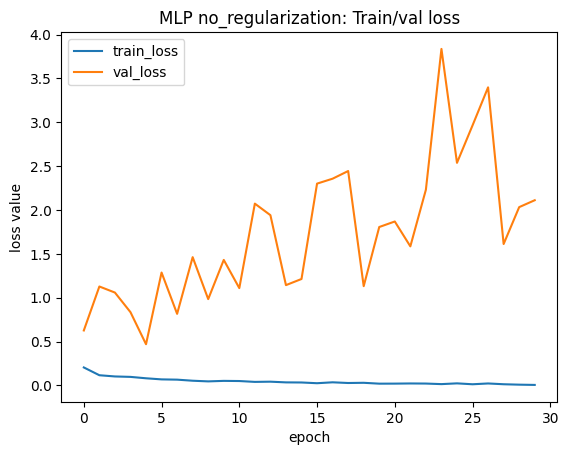

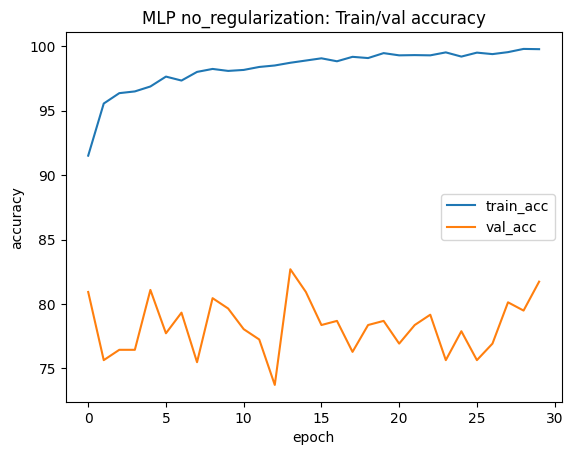

In [50]:
plot(train_losses, val_losses, train_acc, val_acc, title='MLP no_regularization')

In [51]:
val_loss_mlp, val_accuracy_mlp = evaluate(model, val_loader, loss_fn)
print('Early stopping. Validation loss: {:.4f}, validation accuracy: {:.4f}'.format(val_loss_mlp, val_accuracy_mlp))

Early stopping. Validation loss: 2.1111, validation accuracy: 81.7308


In [52]:
model2 = model2.to(device)
learning_rate = 1e-3
optimizer = torch.optim.Adam(model2.parameters(), lr=learning_rate)
n_epochs = 30
loss_fn = nn.CrossEntropyLoss()
train_losses2, val_losses2, train_acc2, val_acc2 = train(model2, train_loader, val_loader, optimizer, n_epochs, loss_fn)

  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 1/30: train_loss: 0.3100, train_accuracy: 86.3113, val_loss: 0.3021, val_accuracy: 86.6987


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 2/30: train_loss: 0.1268, train_accuracy: 95.0345, val_loss: 0.8209, val_accuracy: 74.1987


  0%|          | 0/163 [00:00<?, ?it/s]

...

Epoch 28/30: train_loss: 0.0104, train_accuracy: 99.6166, val_loss: 1.3148, val_accuracy: 79.1667


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 29/30: train_loss: 0.0108, train_accuracy: 99.7316, val_loss: 1.6552, val_accuracy: 80.2885


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 30/30: train_loss: 0.0212, train_accuracy: 99.1756, val_loss: 1.8413, val_accuracy: 76.4423


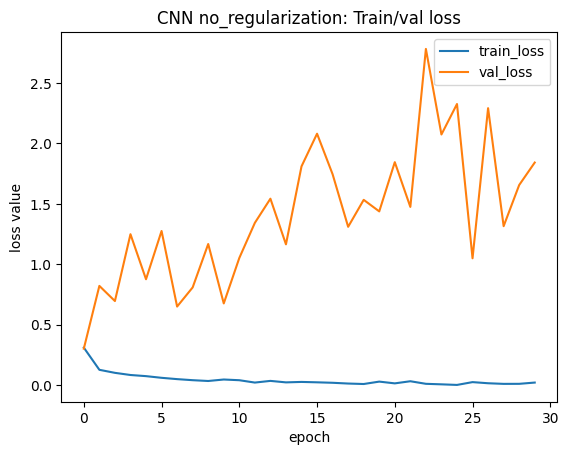

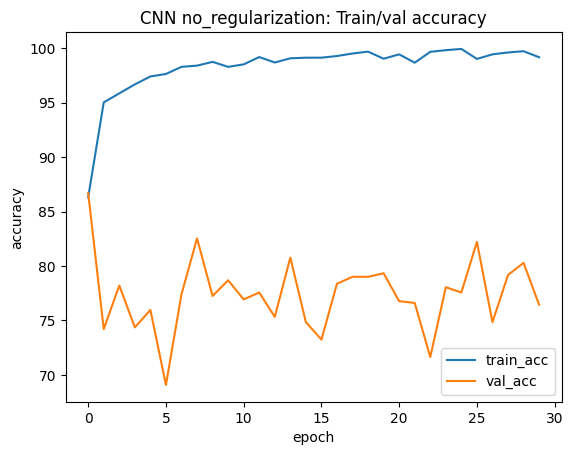

In [53]:
plot(train_losses2, val_losses2, train_acc2, val_acc2, title='CNN no_regularization')

In [54]:
val_loss_no_reg, val_accuracy_no_reg = evaluate(model2, val_loader, loss_fn)
print('Early stopping. Validation loss: {:.4f}, validation accuracy: {:.4f}'.format(val_loss_no_reg, val_accuracy_no_reg))

Early stopping. Validation loss: 1.8413, validation accuracy: 76.4423


# Early stopping

In [55]:
from copy import deepcopy

def train_early_stopping(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_function):
    # We will monitor loss functions as the training progresses
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    ### EARLY STOPPING INITIALIZATION
    best_val_accuracy = 0.
    best_model = None
    patience = 5 # if no improvement after 10 epochs, stop training
    counter = 0
    ###

    for epoch in range(n_epochs):
        model.train()
        train_loss, train_accuracy = train_epoch(model, train_dataloader, optimizer, loss_fn)
        model.eval()
        val_loss, val_accuracy = evaluate(model, val_dataloader, loss_fn)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        print('Epoch {}/{}: train_loss: {:.4f}, train_accuracy: {:.4f}, val_loss: {:.4f}, val_accuracy: {:.4f}'.format(epoch+1, n_epochs,
                                                                                                      train_losses[-1],
                                                                                                      train_accuracies[-1],
                                                                                                      val_losses[-1],
                                                                                                      val_accuracies[-1]))
    
        ### EARLY STOPPING CODE
        if val_accuracy > best_val_accuracy: # If validation loss improved, save the model and reset the counter
            best_val_accuracy = val_accuracy
            best_model = deepcopy(model)
            counter = 0
        else: # If validation loss not improved, increase the counter
            counter += 1
        if counter == patience: # If no improvement for some number of epochs, stop training
            print('No improvement for {} epochs; training stopped.'.format(patience))
            break
    # Copy best model parameters to model
    for param1, param2 in zip(model.parameters(), best_model.parameters()):
        param1.data = param2.data
    ###
    return train_losses, val_losses, train_accuracies, val_accuracies

In [56]:
model3 = ConvModel()
model3 = model3.to(device)
learning_rate = 1e-3
optimizer = torch.optim.Adam(model3.parameters(), lr=learning_rate)
n_epochs = 30
loss_function = nn.CrossEntropyLoss()

train_losses_es, val_losses_es, train_acc_es, val_acc_es = train_early_stopping(model3, train_loader, val_loader, optimizer, n_epochs, loss_fn)

  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 1/30: train_loss: 0.3234, train_accuracy: 85.5253, val_loss: 0.5459, val_accuracy: 76.9231


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 2/30: train_loss: 0.1170, train_accuracy: 95.5330, val_loss: 0.6899, val_accuracy: 75.6410


  0%|          | 0/163 [00:00<?, ?it/s]

...

Epoch 12/30: train_loss: 0.0289, train_accuracy: 98.8113, val_loss: 1.1825, val_accuracy: 75.0000


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 13/30: train_loss: 0.0265, train_accuracy: 99.0414, val_loss: 1.4848, val_accuracy: 72.4359


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 14/30: train_loss: 0.0195, train_accuracy: 99.2331, val_loss: 1.7106, val_accuracy: 78.2051
No improvement for 5 epochs; training stopped.


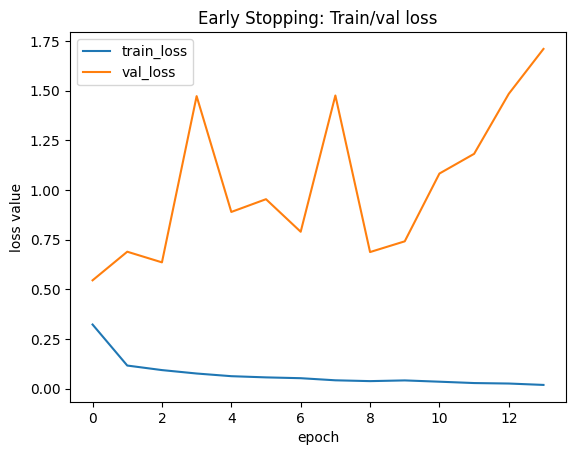

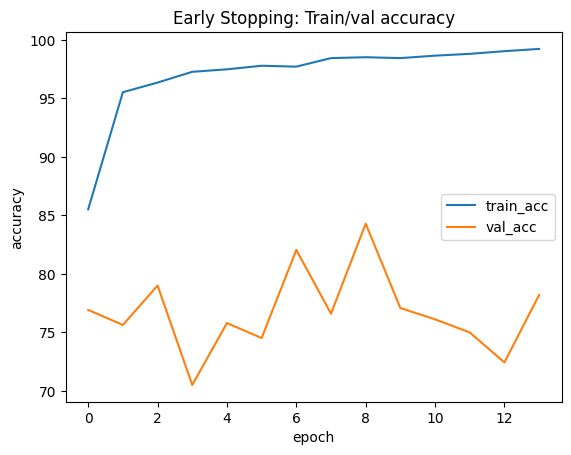

In [57]:
plot(train_losses_es, val_losses_es, train_acc_es, val_acc_es, title='Early Stopping')

In [58]:
# Evaluate on best model
val_loss_early_stopping, val_accuracy_early_stopping = evaluate(model3, val_loader, loss_fn)
print('Early stopping. Validation loss: {:.4f}, validation accuracy: {:.4f}'.format(val_loss_early_stopping, val_accuracy_early_stopping))

Early stopping. Validation loss: 0.6882, validation accuracy: 84.2949


# L2 regularization / weight decay

In [59]:
model4 = ConvModel()
model4 = model4.to(device)
learning_rate = 1e-3
alpha = 0.0075 # If too big - the network won't train at all (weights will be zero)
optimizer = torch.optim.Adam(model4.parameters(), lr=learning_rate, weight_decay=alpha)
n_epochs = 30
loss_fn = nn.CrossEntropyLoss()

In [60]:
train_losses_wd, val_losses_wd, train_acc_wd, val_acc_wd = train(model4, train_loader, val_loader, optimizer, n_epochs, loss_fn)

  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 1/30: train_loss: 0.3494, train_accuracy: 84.2983, val_loss: 0.3640, val_accuracy: 85.7372


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 2/30: train_loss: 0.1943, train_accuracy: 92.5805, val_loss: 0.3943, val_accuracy: 82.2115


  0%|          | 0/163 [00:00<?, ?it/s]

...

Epoch 28/30: train_loss: 0.0585, train_accuracy: 97.6994, val_loss: 0.8104, val_accuracy: 76.1218


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 29/30: train_loss: 0.0517, train_accuracy: 97.9870, val_loss: 0.6942, val_accuracy: 78.2051


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 30/30: train_loss: 0.0514, train_accuracy: 97.8719, val_loss: 0.7175, val_accuracy: 79.8077


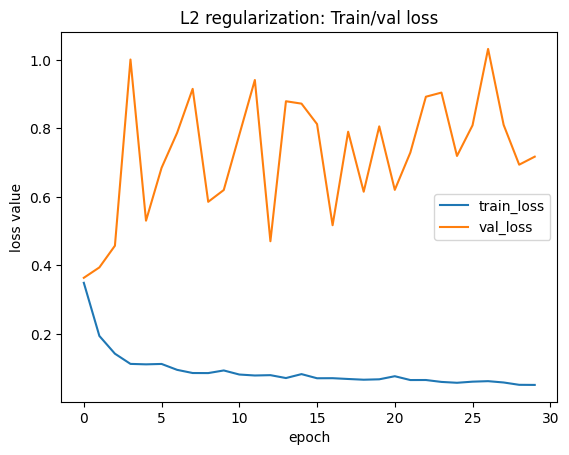

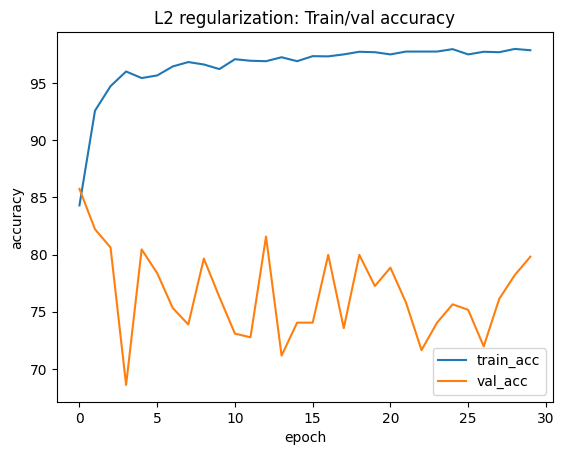

In [61]:
plot(train_losses_wd, val_losses_wd, train_acc_wd, val_acc_wd, title='L2 regularization')

In [62]:
val_loss_weightdecay, val_accuracy_weightdecay = val_losses_wd[-1], val_acc_wd[-1]
print('L2 regularization. Validation loss: {:.4f}, validation accuracy: {:.4f}'.format(val_loss_weightdecay, val_accuracy_weightdecay))

L2 regularization. Validation loss: 0.7175, validation accuracy: 79.8077


# Results comparison

In [63]:
table_data = [
    ['Regularization type', 'Val Loss', 'Val accuracy'],
    ['MLP Model', val_loss_mlp, val_accuracy_mlp],
    ['CNN No reg', val_loss_no_reg, val_accuracy_no_reg], 
    ['Early stopping', val_loss_early_stopping, val_accuracy_early_stopping],
    ['L2 regularization', val_loss_weightdecay, val_accuracy_weightdecay],
]
print("{: >20}| {: >20}| {: >20}".format(*table_data[0]))
print('-'.join(['' for i in range(65)]))
for row in table_data[1:]:
    print("{: >20}| {:20.4f}| {: >20}".format(*row))

 Regularization type|             Val Loss|         Val accuracy
----------------------------------------------------------------
           MLP Model|               2.1111|    81.73076923076923
          CNN No reg|               1.8413|     76.4423076923077
      Early stopping|               0.6882|     84.2948717948718
   L2 regularization|               0.7175|     79.8076923076923


In [64]:
loss_curves = [val_losses, val_losses2, val_losses_es, val_losses_wd]
reg_types = ['MLP', 'CNN no regularization', 'early stopping', 'l2 regularization']

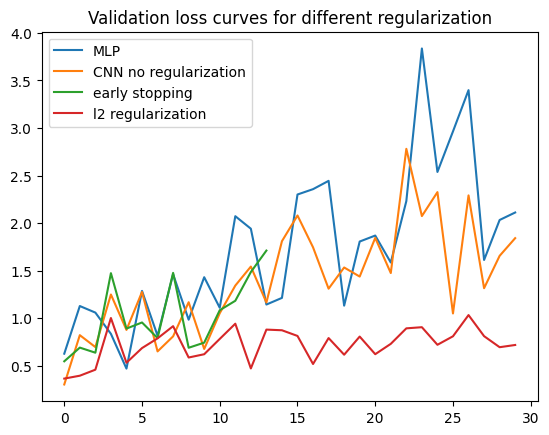

In [65]:
for loss_curve in loss_curves:
    plt.plot(np.arange(len(loss_curve)), loss_curve)
plt.title('Validation loss curves for different regularization')
plt.legend(reg_types);

In [ ]:
# Judging by my outputs, the early stopping achieved the best results.
# I believe they all flattened quickly due to the small sample size
# Other regularization techniques such as dropout or data augmentation could have helped, especially because the training dataset was very small, which also limits the growth of the model.
# The model could pitentially be too complicated for the dataset leading to overfitting. It's also possible that the learning rate is too high leading to a plateau quickly.
# The early stopping could've performed the best as models tend to decrease in performance after they get to a certain point and the sample size is too small to train with 30 epochs.